# MES Keltner-squeeze / VWAP breakout (Tradovate exchange)

Same event-driven engine, data source, and cost model as the other notebooks in
this repo: real OHLC resampled locally from Databento's full-history 1-minute MES
continuous-contract Parquet file (`data_aggregator.databento_aggregator`,
GLBX.MDP3, `MES.c.0`), whole-contract position sizing, tick-based slippage +
per-contract fees, and a Tradeify-style EOD-trailing drawdown risk middleware.

**Strategy** (`backtester.strategies.KeltnerVwapBreakoutStrategy`, new this
pass): the exact same shape as the already-tested
`BollingerVwapBreakoutStrategy` (`bollinger_vwap_breakout_mes.ipynb`), with
**Keltner Channels** (`Indicators.keltner_channels` -- an EMA midline +/- an
ATR-scaled band) in place of Bollinger Bands (an SMA midline +/- a std-dev
band):

1. **Keltner Channels** define the *setup*: band width `(upper - lower) /
   middle` is compared against its own rolling percentile, and a "squeeze" is
   flagged whenever band width is unusually narrow for that lookback window --
   identical squeeze logic to the Bollinger version, just fed an ATR-based band
   instead of a std-dev-based one.
2. **Session VWAP** supplies the *direction*, exactly as before: price above
   VWAP -> long, below -> short, at the moment a squeeze is flagged.

**Why test this at all, given the Bollinger version's result** (spoiler from
that notebook's findings: net-negative across every combo, win rate sitting
almost exactly at the 1:2 payout's 33.3% breakeven -- "barely an edge to begin
with," not costs eroding a real one): ATR reacts to realized high-low range as
it happens, where a std-dev band only widens *after* a move has already moved
the variance of closes. If Bollinger's problem was the band construction itself
(too slow to reflect an approaching move) rather than the VWAP-direction logic,
Keltner should look different. If the two land in the same place, that's
further evidence the marginal result is about the squeeze/VWAP mechanism, not
which specific band type feeds it.

**Risk**: stop-loss at the *opposite* band, take-profit at a fixed **1:2
risk:reward** multiple of that stop -- identical convention to every other
strategy in this pipeline. Total fees paid are tracked directly from the
exchange event log, and frictionless trade-level metrics (`profit_factor`,
`r_multiple_expectancy`) are reported alongside the costed ones, per this
pipeline's established `gross_return_percent` caveat (it's the final wealth
multiple x100, not a pre-fee return, and carries no cost information on its
own).


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import KeltnerVwapBreakoutStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    # Different notebook runners launch the kernel with different cwds -- walk upward
    # until the target exists instead of assuming a fixed number of parent hops.
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MES"
SYMBOL = "MES/USD"
INTERVAL = 5
UNIT_OF_TIME = "minute"

mes_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(mes_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 504547  span: 2019-05-05 22:04:59.999000 -> 2026-07-12 23:09:59.999000


## Indicators: Keltner Channels, band-width squeeze, session VWAP

`SQUEEZE_LOOKBACK`/`SQUEEZE_PERCENTILE` control how "narrow" counts as a squeeze,
identical definition to the Bollinger notebook: band width has to be at or below
its own `SQUEEZE_PERCENTILE`-th percentile over the trailing `SQUEEZE_LOOKBACK`
bars. `KC_ATR_MULT=2.0` and `KC_ATR_LENGTH=10` are held at their standard
defaults (mirroring `BB_STD_DEV=2.0` being held fixed in the Bollinger notebook);
`KC_LENGTH` (EMA midline period) and `SQUEEZE_PERCENTILE` are grid-searched
below, at the exact same candidate values as the Bollinger notebook's
`BB_LENGTH`/`SQUEEZE_PERCENTILE` grid, so the two are directly comparable.


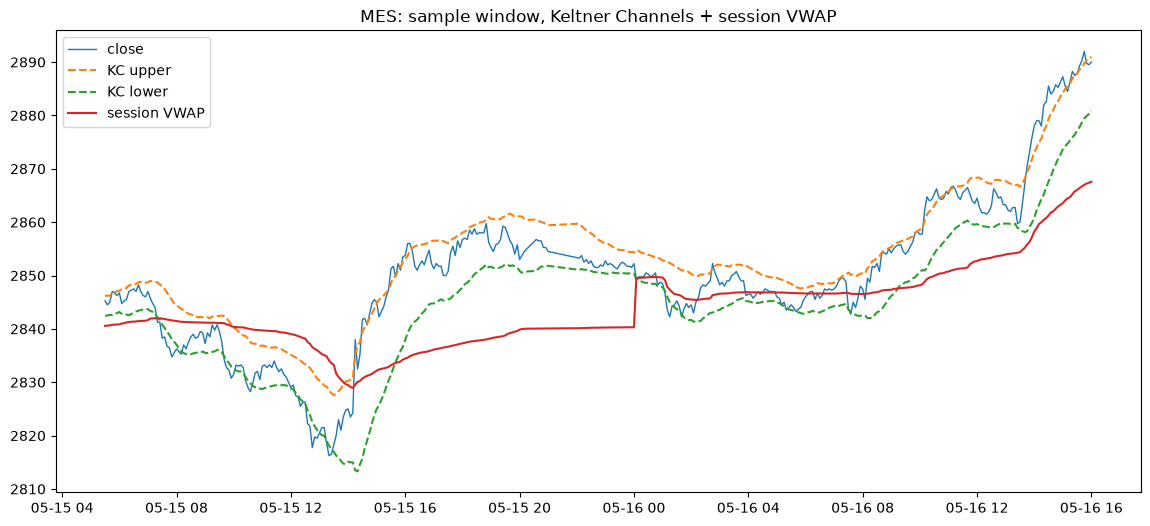

In [3]:
KC_LENGTH = 20
KC_ATR_LENGTH = 10
KC_ATR_MULT = 2.0
SQUEEZE_LOOKBACK = 100

kc_lower, kc_middle, kc_upper = Indicators.keltner_channels(
    ohlc, length=KC_LENGTH, atr_length=KC_ATR_LENGTH, atr_mult=KC_ATR_MULT
)
vwap, vwap_std = Indicators.vwap_session(ohlc)

# Sample window plot -- sanity check that bands/VWAP look like what they should
# before trusting anything derived from them.
_sample = slice(2000, 2400)
plt.figure(figsize=(14, 6))
plt.plot(ohlc.index[_sample], ohlc["close"].iloc[_sample], label="close", linewidth=1)
plt.plot(ohlc.index[_sample], kc_upper.iloc[_sample], label="KC upper", linestyle="--")
plt.plot(ohlc.index[_sample], kc_lower.iloc[_sample], label="KC lower", linestyle="--")
plt.plot(ohlc.index[_sample], vwap.iloc[_sample], label="session VWAP")
plt.legend()
plt.title(f"{DISPLAY_SYMBOL}: sample window, Keltner Channels + session VWAP")
plt.show()


## Grid search: KC length x squeeze percentile

`risk_reward_ratio=2.0`, `KC_ATR_MULT=2.0`, `KC_ATR_LENGTH=10` held fixed --
stated conventions, not free parameters to tune away from. `KC_LENGTH` and
`SQUEEZE_PERCENTILE` are the two genuinely open questions, same as the Bollinger
notebook's grid. Total fees paid are pulled directly from the exchange event log
for every combination, alongside return/Sharpe/drawdown and the frictionless
trade-level metrics.


In [4]:
KC_LENGTH_CANDIDATES = [20, 30]
SQUEEZE_PERCENTILE_CANDIDATES = [0.10, 0.20]
RISK_REWARD_RATIO = 2.0
DEPOSIT_USD = 50_000  # Tradeify Growth $50k account, same convention as the other notebooks


def build_squeeze_indicators(kc_length: int, squeeze_percentile: float):
    lower, middle, upper = Indicators.keltner_channels(
        ohlc, length=kc_length, atr_length=KC_ATR_LENGTH, atr_mult=KC_ATR_MULT
    )
    width = (upper - lower) / middle
    threshold = width.rolling(SQUEEZE_LOOKBACK).quantile(squeeze_percentile)
    is_squeeze = width <= threshold
    return lower, upper, is_squeeze


def run_breakout_backtest(kc_length: int, squeeze_percentile: float):
    lower, upper, is_squeeze = build_squeeze_indicators(kc_length, squeeze_percentile)

    combo_market = Market()
    combo_market.add_market(symbol=SYMBOL, df=ohlc)
    combo_market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                indicator_name="vwap", df=vwap)
    combo_market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                indicator_name="kc_lower", df=lower)
    combo_market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                indicator_name="kc_upper", df=upper)
    combo_market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                indicator_name="is_squeeze", df=is_squeeze)
    combo_market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(
            weight=1.0,
            strategy=KeltnerVwapBreakoutStrategy(
                key=f"KC_BREAKOUT_{kc_length}_{squeeze_percentile}_MES",
                market=combo_market,
                symbol=SYMBOL,
                vwap_indicator_key="vwap",
                kc_lower_key="kc_lower",
                kc_upper_key="kc_upper",
                squeeze_indicator_key="is_squeeze",
                risk_reward_ratio=RISK_REWARD_RATIO,
                direction=StrategyDirection.both,
            ),
        ),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=combo_market,
        slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future,
        max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(
        market=combo_market, exchange=exchange, portfolio=portfolio,
        benchmark_symbols=[SYMBOL], periods_per_year=252,
    )

    combo_market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(
        market=combo_market, portfolio=portfolio, exchange=exchange, reporter=reporter,
        middlewares=[daily_loss_middleware, drawdown_middleware],
    )
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


grid_rows = []
grid_backtests = {}
for kc_length in KC_LENGTH_CANDIDATES:
    for squeeze_percentile in SQUEEZE_PERCENTILE_CANDIDATES:
        _t0 = time.time()
        bt, drawdown_mw = run_breakout_backtest(kc_length, squeeze_percentile)
        print(f"kc_length={kc_length} squeeze_pct={squeeze_percentile} done in {time.time() - _t0:.1f}s", flush=True)
        summary = bt.reporter.summary["algo"]
        total_fees = sum(
            e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled)
        )
        grid_backtests[(kc_length, squeeze_percentile)] = (bt, drawdown_mw)
        grid_rows.append({
            "kc_length": kc_length, "squeeze_percentile": squeeze_percentile,
            "net_return_percent": summary["net_return_percent"],
            "sharpe_ratio": summary["sharpe_ratio"],
            "max_drawdown_percent": summary["max_drawdown_percent"],
            "closed_trades": summary["closed_trades"],
            "trades_per_year": round(summary["closed_trades"] / 7.2, 1),
            "win_rate_percent": summary["win_rate_percent"],
            "profit_factor": summary["profit_factor"],
            "r_multiple_expectancy": summary["r_multiple_expectancy"],
            "dollar_profit_factor": summary["dollar_profit_factor"],
            "dollar_expectancy": summary["dollar_expectancy"],
            "total_fees_usd": total_fees,
            "account_failed": drawdown_mw.account_failed,
        })

grid_results = pd.DataFrame(grid_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print(grid_results.to_string())


kc_length=20 squeeze_pct=0.1 done in 74.4s


kc_length=20 squeeze_pct=0.2 done in 102.4s


kc_length=30 squeeze_pct=0.1 done in 76.1s


kc_length=30 squeeze_pct=0.2 done in 78.6s


   kc_length  squeeze_percentile  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0         30                 0.1          -34.189038     -0.625590              -38.9379         3561.0            494.6         33.164841       1.044275              -0.003403              0.942836          -2.564750         8736.00           False
1         20                 0.1          -34.117525     -0.698914              -35.0112         3979.0            552.6         34.028650       1.065208               0.022308              0.953009          -1.913499        10095.54           False
2         30                 0.2          -48.236325     -0.973108              -48.4162         3734.0            518.6         33.074451       1.011293              -0.005873              0.863906          -6.423109         7007.00           False


## Detailed report for the best (kc_length, squeeze_percentile)

Full HTML summary (year-by-year split) and equity/drawdown charts for whichever
combo above ranked best by Sharpe -- same report format as the other notebooks.


Best combo: kc_length=30, squeeze_percentile=0.1
Candles Processed: 504546
Account failed (drawdown breach): False
Drawdown floor locked (reached profit buffer): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,-0.6256,-2.2644,-0.0489,-1.6785,-1.8066,-1.3569,-0.9555,0.8355,-0.9866,0.6392,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,-0.9163,-3.0399,-0.0725,-2.1257,-2.5255,-1.9152,-1.3689,1.4235,-1.2176,0.9137,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,6.1213,4.6398,11.9665,4.2092,5.1418,3.0408,3.7412,6.3951,2.5377,16.6830,How much the equity curve swings per year. Lower = smoother.
cagr_percent,-5.6515,-14.2520,-1.8650,-9.8696,-12.7903,-5.8801,-5.1557,7.7501,-3.6249,14.3689,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,-0.1451,-1.3418,-0.1132,-0.8375,-0.9611,-0.6373,-0.6363,2.3531,-1.8846,0.4057,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,-0.8780,-0.9053,-0.1132,-0.8353,-0.9586,-0.6356,-0.6363,2.3464,-1.0000,4.5918,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-38.9379,-10.6219,-16.4737,-11.7843,-13.3086,-9.2271,-8.1028,-3.2936,-1.9235,-35.4168,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,2590,205,288,346,350,300,215,126,126,719,How long it took to recover the loss. Shorter is better.
ulcer_index,27.5654,5.6717,10.9752,8.2556,9.0675,5.4200,3.6036,1.6435,1.4098,8.4634,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.4808,-0.5028,-0.8971,-0.4322,-0.5054,-0.3172,-0.3766,-0.4827,-0.1555,-1.4858,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


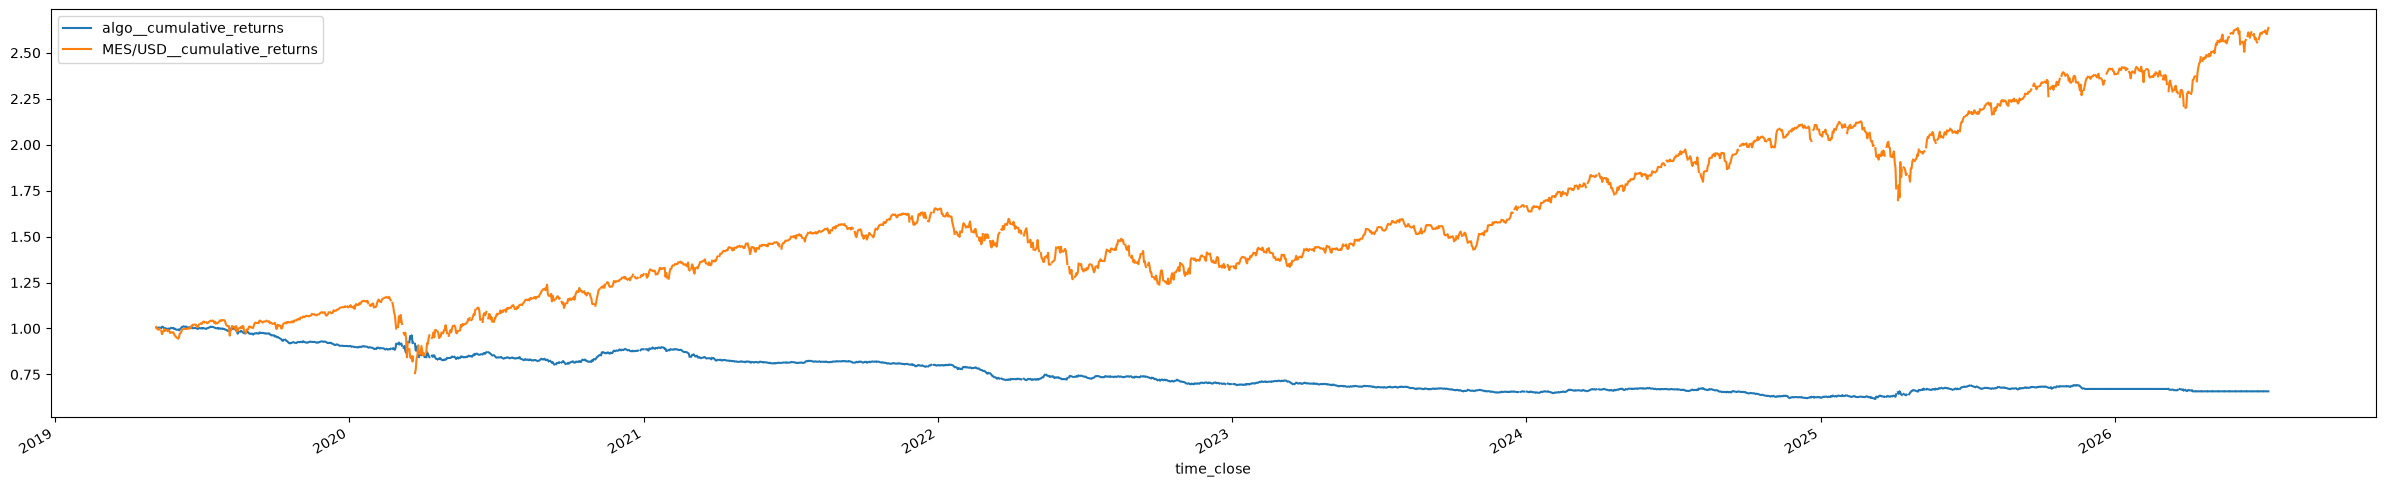

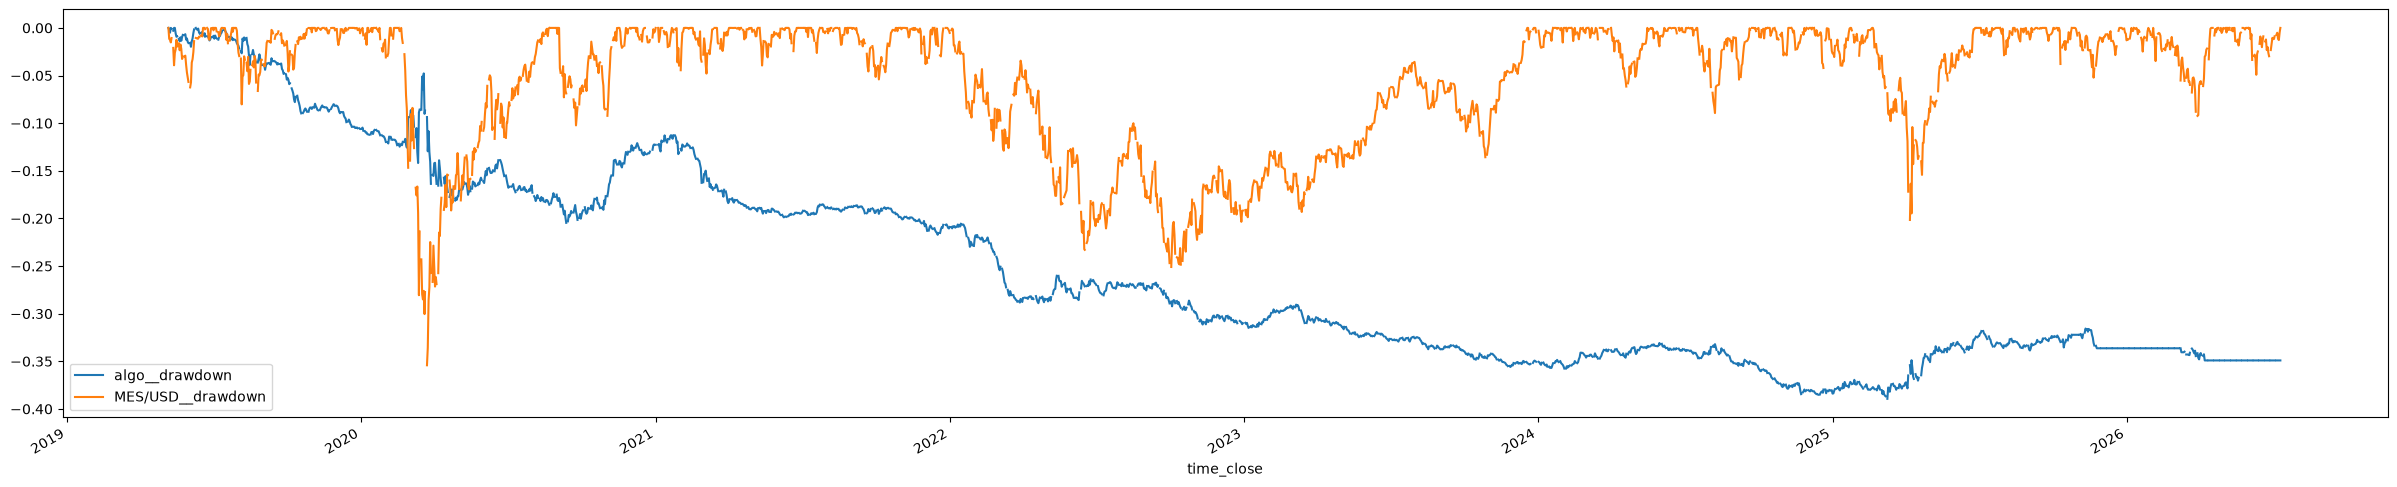

In [5]:
best_kc_length, best_squeeze_pct = grid_results.iloc[0][["kc_length", "squeeze_percentile"]]
best_kc_length = int(best_kc_length)
print(f"Best combo: kc_length={best_kc_length}, squeeze_percentile={best_squeeze_pct}")
best_backtest, best_drawdown_mw = grid_backtests[(best_kc_length, best_squeeze_pct)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)
print("Drawdown floor locked (reached profit buffer):", best_drawdown_mw.locked)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Findings

**Lands in essentially the same marginal, cost-negative place as the Bollinger
version -- the band type wasn't the problem.** All numbers from the real
event-driven engine (real Tradovate/Tradeify cost model), 2019-05-05 ->
2026-07-12, 504,547 5-minute bars.

| kc_length | squeeze_pct | net_return | sharpe | trades | win_rate | profit_factor | dollar_profit_factor | dollar_expectancy | account_failed |
|---|---|---|---|---|---|---|---|---|---|
| **30 (best)** | **0.1** | **-34.2%** | -0.626 | 3561 | 33.16% | 1.044 | 0.943 | -$2.56/trade | False |
| 20 | 0.1 | -34.1% | -0.699 | 3979 | 34.03% | 1.065 | 0.953 | -$1.91/trade | False |
| 30 | 0.2 | -48.2% | -0.973 | 3734 | 33.07% | 1.011 | 0.864 | -$6.42/trade | False |
| 20 | 0.2 | -49.4% | -1.111 | 2672 | 32.63% | 0.938 | 0.862 | -$6.29/trade | **True** |

**Direct comparison to the Bollinger notebook's best combo** (`bb_length=30,
squeeze_percentile=0.2`: net -41.4%, sharpe -0.80, win rate 33.49%,
`profit_factor` 1.057, `dollar_expectancy` -$2.01 to -$7.10/trade): this
Keltner version's best combo (`kc_length=30, squeeze_percentile=0.1`) is in the
same ballpark on every metric that matters -- net return in the -34% to -49%
range across all 4 combos (vs. Bollinger's -41% to -50%), win rate sitting right
at or just under the 33.3% breakeven for a 1:2 payout every single time (32.6%
to 34.0%, vs. Bollinger's 32.3%-33.5%), and `dollar_profit_factor` under 1.0 in
3 of 4 combos (vs. all 4 for Bollinger). `kc_length=20, squeeze_percentile=0.2`
even breached the drawdown middleware, same failure mode as Bollinger's
`bb_length=20` combos.

**This confirms the hypothesis stated up front**: if the marginal result were
specifically a Bollinger-band artifact (bands too slow to reflect an approaching
move, since std-dev only widens after a move has already happened), an ATR-based
Keltner band should have looked meaningfully different. It didn't. The problem is
almost certainly upstream of the band construction -- either the band-width
percentile squeeze itself isn't a reliable "expansion is coming" signal on MES
at this timeframe, or VWAP-side isn't predictive of *which way* a squeeze
resolves (both bands still leave direction to a single VWAP snapshot with no
corroborating evidence, and the Bollinger notebook's own follow-up pass already
found an EMA trend-agreement filter didn't fix that either). **Bottom line**:
this is now the second band-squeeze/VWAP-direction implementation to land at the
same marginal, near-breakeven-win-rate result -- reasonably strong evidence
against the underlying squeeze-and-fade-VWAP-direction mechanism itself, not
just against one specific band type or filter.
